# Task 3a: YCSEP preparation and Parakeet fine-tuning

Selected E3 completed 3,000 updates in 160.79 fit minutes. Native non-TDK validation WER improved from 32.2042% to 24.6470%. This notebook defaults to recorded E3 evidence; opt-in training uses the same 3,000-update configuration. All TDK is excluded from training and validation. Historical E1 and E2 evidence is retained separately.


In [1]:
import json, os, sys
from pathlib import Path
root = Path.cwd().resolve()
if root.name == 'asr-train':
    root = root.parent
sys.path.insert(0, str(root / 'asr-train'))
from prepare_metadata import prepare
source = Path(os.environ.get('YCSEP_CSV', str(root / 'test_docs/test/runtime/local-prep-0316/data/YCSEP_static.csv')))
output = Path(os.environ.get('YCSEP_AUDIT', str(root / 'test_docs/test/runtime/metadata-audit')))
print('Source:', source)
print('Output:', output)
recorded = root / 'asr-train/results/E3'
retrain = os.environ.get('RUN_TRAINING') == '1'

Source: C:\Users\Sneha\Downloads\HTX-xData-Technical-Test\test_docs\test\runtime\local-prep-0316\data\YCSEP_static.csv
Output: C:\Users\Sneha\Downloads\HTX-xData-Technical-Test\test_docs\test\runtime\metadata-audit


## Freeze the split before curation

All TDK source-video IDs and audio URLs are held out. Non-TDK videos receive a deterministic hash-based train/validation split, seed 2026, expected validation fraction 10%. The realized fraction need not equal 10%. Video grouping reduces adjacent-clip leakage but does not prove speaker independence. Near-duplicate audio requires a later acoustic check.

The CPU candidate policy retains original transcripts and Singlish. Invalid timestamps, empty lexical text, invalid URLs, duplicate URLs and durations outside 0.3-20 seconds are excluded from the pilot candidate pool. Sparse/dense text, fillers and repeated characters remain flags. Validation receives only objective validity checks; later learned quality thresholds must not redefine it to improve reported performance.

In [2]:
if (recorded / 'audit.json').exists() and not retrain:
    audit = json.loads((recorded / 'audit.json').read_text())
else:
    assert source.exists(), 'Set YCSEP_CSV to the supplied dataset'
    audit = prepare(source, output)
audit

{'source_sha256': 'a76ea7653b2025bb934e14ecba1c6e5aebdfdb836af6264fb870b7b03316ce83',
 'seed': 2026,
 'validation_fraction': 0.1,
 'rows': 757072,
 'channel_rows': {'Historyogi': 16358,
  'NOTG': 65155,
  'Randomly_Relatable_SG': 26005,
  'The_Daily_Ketchup_Podcast': 218011,
  'Yah_Lah_BUT': 347736,
  'YouGotWatch': 83807},
 'channel_segment_hours': {'Historyogi': 15.933716666666726,
  'NOTG': 62.539260555555956,
  'Randomly_Relatable_SG': 17.196140277777737,
  'The_Daily_Ketchup_Podcast': 172.91072749999165,
  'Yah_Lah_BUT': 288.31827722219975,
  'YouGotWatch': 63.39574194444726},
 'channel_videos': {'Historyogi': 43,
  'NOTG': 134,
  'Randomly_Relatable_SG': 82,
  'The_Daily_Ketchup_Podcast': 367,
  'Yah_Lah_BUT': 372,
  'YouGotWatch': 314},
 'duration_buckets': {'5-10': 107179,
  '1-5': 397496,
  '0.3-0.5': 47091,
  '0.5-1': 102977,
  '<0.3': 74070,
  '10-15': 21228,
  '15-20': 4976,
  '>=20': 2055},
 'non_tdk_flags': {'short': 81954,
  'dense_text': 23853,
  'long': 1357,
  'sparse

## Inspect duration, text and overlap

Segment-hours may count overlapping intervals more than once. The sweep-line overlap report separately measures union time and time covered by at least two annotation intervals. Annotation overlap is not proof of simultaneous speech. TDK metadata is reported for coverage, not used to tune quality rules.

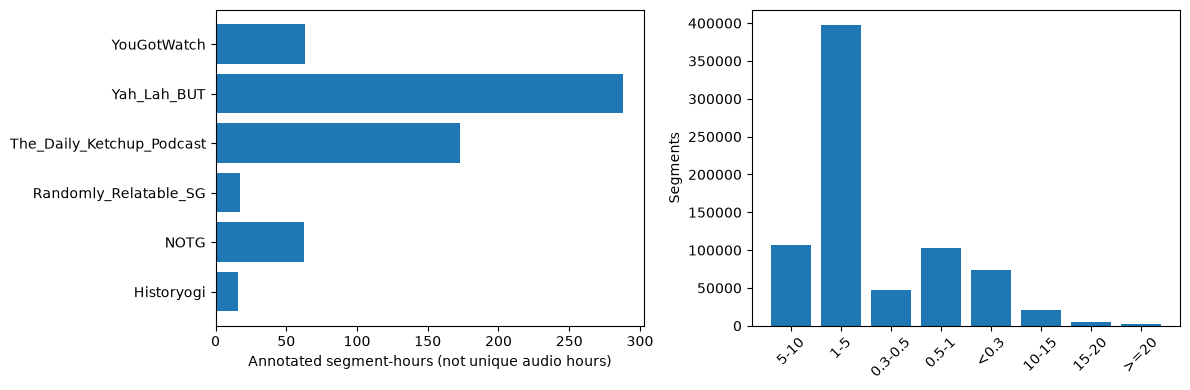

In [3]:
output.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(list(audit['channel_segment_hours']), list(audit['channel_segment_hours'].values()))
axes[0].set_xlabel('Annotated segment-hours (not unique audio hours)')
axes[1].bar(list(audit['duration_buckets']), list(audit['duration_buckets'].values()))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Segments')
fig.tight_layout()
fig.savefig(output / 'metadata_overview.png', dpi=160)
plt.show()

## Audio preparation and feature extraction

The frozen pilot contains 10,972 training clips (10.046 hours) and 2,133 validation clips (2.023 hours), all successfully prepared. CPU preprocessing validates nonzero audio, actual duration and PCM16 mono 16 kHz format. Audio-ready NeMo manifests retain measured duration, original text and source-video provenance. Valid cached audio was reused when the clip service failed; remaining clips were extracted from original source WAV frame ranges. Neither path proves transcript alignment correctness.

Retain the pretrained 8,192-token SentencePiece tokenizer. The recorded acoustic preprocessor uses 128 log-mel features, a 25 ms Hann window, 10 ms stride, FFT size 512 and per-feature normalization at 16 kHz. Keeping these components avoids changing the pretrained model's input/token contracts on a small adaptation set. Retained SpecAugment configuration: two frequency masks (width 27), ten time masks (relative width 0.05). VAD/MOS-based learned curation was not added without evidence that its extra cost would improve selection.

## Executed PyTorch/NeMo experiment

E0: base model native WER on frozen non-TDK validation. E3: full-model fine-tuning on the 10-hour pilot with AdamW, constant learning rate 1e-5, betas (0.9, 0.98), weight decay 0.001, batch size 8, accumulation 4, BF16 and gradient clipping 1.0. The conservative learning rate limits large updates to pretrained weights; accumulation gives a nominal effective batch of 32 without requiring that many examples in GPU memory. BF16 reduces memory demand, and clipping limits unstable gradient spikes. These are justified starting values, not optimized settings. WER/CER for the final paired TDK comparison are calculated in Task 3b.

Validate every 200 microbatches (50 optimizer updates at accumulation 4), with at most 3,000 updates and a 180-minute training budget. Select the lowest non-TDK validation WER. Save the best full Lightning checkpoint including optimizer state; export a portable NeMo inference artifact. Record loss, WER, actual data hours, optimizer, seed, package versions and elapsed time. Historical E2 and excluded E4 are discussed below; no further broad experiments are planned; no TDK-based model selection.

Final artifact: parakeet-tdt-0.6b-v3-ycsep.nemo. The best checkpoint occurred at update 3,000. The experiment stopped at the predeclared update budget, not because convergence or early stopping was established.
Early-stopping patience: 10 checks, minimum absolute WER improvement 0.0005. Early stopping did not trigger. This run starts from pretrained weights, not the excluded E4 resume path.


## Analysis Rules

Compare E0 and E3 on the same validation rows. Decreasing training loss alone does not demonstrate generalization. Inspect worsening validation WER, plateau, corrupted batches and subgroup regressions before scaling. Report failed audio coverage separately. Never replace a missing experiment with a fabricated curve.

References: [Parakeet model card](https://huggingface.co/nvidia/parakeet-tdt-0.6b-v3), [JiWER](https://jitsi.github.io/jiwer/).

## Prepare the frozen audio manifests
The original tokenizer (8,192 tokens) and pretrained acoustic preprocessor are retained. PCM16 mono 16 kHz conversion is performed on CPU. Equal annotated hours per non-TDK channel and round-robin source videos bound the pilot while retaining diversity. Duration checks do not establish transcript correctness. The local execution test exposed a TDT CUDA dependency problem; the training Docker environment pins Numba and NVIDIA numba-cuda and has passed actual optimization.

In [4]:
if not retrain and (recorded / 'training-result.json').exists():
    for split in ['train', 'validation']:
        print(json.loads((recorded / f'{split}-data-report.json').read_text()))
else:
    from argparse import Namespace
    from select_pilot import main as select_pilot
    from prepare_audio import prepare as prepare_audio
    selection = Path(os.environ.get('YCSEP_SELECTION', str(root / 'test_docs/test/runtime/pilot-selection')))
    audio = Path(os.environ.get('YCSEP_AUDIO', str(root / 'test_docs/test/runtime/pilot-audio')))
    if not (selection / 'selection.json').exists():
        select_pilot(Namespace(audit=str(output), output=str(selection), train_hours=10, validation_hours=2))
    for split in ['validation', 'train']:
        if not (audio / f'{split}.jsonl').exists():
            prepare_audio(selection / f'{split}-selected.jsonl', audio, split, workers=16)
        report = json.loads((audio / f'{split}-result.json').read_text())
        assert not report['failures'], f'Unresolved audio failures in {split}'
        print({k:v for k,v in report.items() if k != 'failures'})

{'split': 'train', 'selected': 10972, 'accepted': 10972, 'hours': 10.046078420138889, 'failures': [], 'elapsed_seconds': 1432.554119700013}
{'split': 'validation', 'selected': 2133, 'accepted': 2133, 'hours': 2.022845138888889, 'failures': [], 'elapsed_seconds': 1046.0505266999826}


In [5]:
from train_parakeet import train
experiment = Path(os.environ.get('YCSEP_EXPERIMENT', str(recorded)))
result_path = experiment / 'training-result.json'
if not retrain and result_path.exists():
    print('Recorded Azure experiment; no new training.')
    result = json.loads(result_path.read_text())
else:
    assert retrain, 'Set RUN_TRAINING=1 and input paths explicitly to train'
    assert not result_path.exists(), 'Use a fresh YCSEP_EXPERIMENT directory'
    result = train(audio / 'train.jsonl', audio / 'validation.jsonl', experiment, max_steps=3000, max_minutes=180, early_stopping_patience=10, early_stopping_min_delta=0.0005, retain_optimizer_state=True)
result

Recorded Azure experiment; no new training.


{'elapsed_training_seconds': 9647.236134155999,
 'optimizer_steps': 3000,
 'best_checkpoint': 'parakeet-step=3000-val_wer=0.2465.ckpt',
 'best_validation_wer': 0.24646978080272675,
 'peak_cuda_memory_bytes': 36331534336,
 'gpu': 'NVIDIA A100 80GB PCIe',
 'status': 'completed',
 'baseline_validation': [{'global_step': 0.0, 'val_wer': 0.3220418393611908}],
 'stop_reason': 'max_steps',
 'early_stopping_wait_count': 0,
 'convergence_note': 'A plateau criterion is not proof of mathematical or global convergence'}

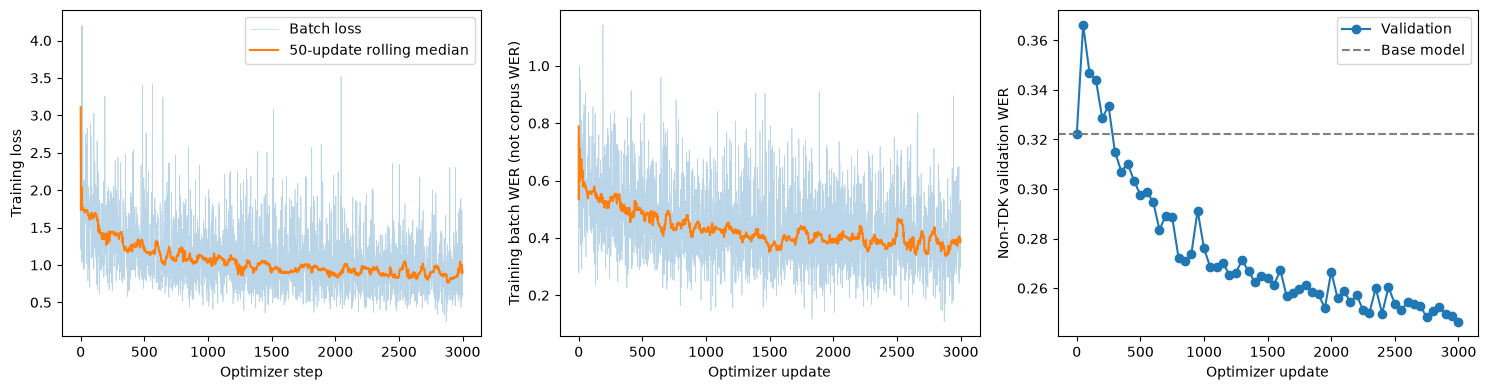

Base native validation WER: 0.3220; selected FT: 0.2465
Training time: 160.8 minutes; updates: 3000


In [6]:
import pandas as pd
metrics_path = sorted((experiment / 'training').glob('version_*/metrics.csv'))[-1]
metrics = pd.read_csv(metrics_path)
loss_column = next(c for c in ['train_loss', 'train_loss_step', 'loss'] if c in metrics.columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss = metrics.dropna(subset=[loss_column])
validation = metrics.dropna(subset=['val_wer'])
axes[0].plot(loss['global_step'], loss[loss_column], linewidth=0.5, alpha=0.3, label='Batch loss')
axes[0].plot(loss['global_step'], loss[loss_column].rolling(50, min_periods=1).median(), label='50-update rolling median')
axes[0].legend()
axes[0].set(xlabel='Optimizer step', ylabel='Training loss')
batch_wer = metrics.dropna(subset=['training_batch_wer'])
axes[1].plot(batch_wer['global_step'], batch_wer['training_batch_wer'], linewidth=0.5, alpha=0.3)
axes[1].plot(batch_wer['global_step'], batch_wer['training_batch_wer'].rolling(50, min_periods=1).median())
axes[1].set(xlabel='Optimizer update', ylabel='Training batch WER (not corpus WER)')
axes[2].plot(validation['global_step'], validation['val_wer'], marker='o', label='Validation')
axes[2].axhline(result['baseline_validation'][0]['val_wer'], color='gray', linestyle='--', label='Base model')
axes[2].set(xlabel='Optimizer update', ylabel='Non-TDK validation WER')
axes[2].legend()
fig.tight_layout()
fig.savefig(output / 'replayed-training-curves.png', dpi=160)
plt.show()
baseline = result['baseline_validation'][0]['val_wer']
print(f"Base native validation WER: {baseline:.4f}; selected FT: {result['best_validation_wer']:.4f}")
print(f"Training time: {result['elapsed_training_seconds']/60:.1f} minutes; updates: {result['optimizer_steps']}")

## Interpretation
Native validation WER falls from 32.2042% to 24.6470%, compared with E1 26.5402% on the same split. Training loss decreases but batch WER and loss remain noisy; neither substitutes for held-out validation. The best checkpoint is at step 3,000, so convergence is not established. Native validation and normalized TDK WER must not be compared directly. No denoising, quality-model filtering or tokenizer replacement was performed.


## Final experiment review: E3 and excluded E4
E3 uses the exact E1 train/validation manifests and unchanged preprocessing, tokenizer, feature extraction, optimizer, seed and batching. It restarts from the original pretrained model and extends the budget to 3,000 updates. Its best native validation WER is 24.6470%, versus E1 26.5402%, at the last update. This supports longer adaptation on this dataset, not proven convergence. Training took 160.79 minutes. Validation, not TDK performance, motivated this candidate.

E2 used 25.046 hours at 1,200 updates and reached 26.6967%; this does not show that more data is intrinsically harmful, since data exposure differs. E4 resumed E3 but inherited Timer state and produced an inconsistent validation score at the resume step. Its 14.93% value and selected artifact are excluded. Later E4 checks offered only marginal apparent gains. No further GPU experiments are needed for this submission.

The preceding cells reproduce selected E3; E1 remains as a historical comparison. E3 can be reproduced with the same manifests and `train(..., max_steps=3000, max_minutes=180, early_stopping_patience=10, early_stopping_min_delta=0.0005, retain_optimizer_state=True)`. Do not use the quarantined E4 resume path.


{'elapsed_training_seconds': 9647.236134155999, 'optimizer_steps': 3000, 'best_checkpoint': 'parakeet-step=3000-val_wer=0.2465.ckpt', 'best_validation_wer': 0.24646978080272675, 'peak_cuda_memory_bytes': 36331534336, 'gpu': 'NVIDIA A100 80GB PCIe', 'status': 'completed', 'baseline_validation': [{'global_step': 0.0, 'val_wer': 0.3220418393611908}], 'stop_reason': 'max_steps', 'early_stopping_wait_count': 0, 'convergence_note': 'A plateau criterion is not proof of mathematical or global convergence'}


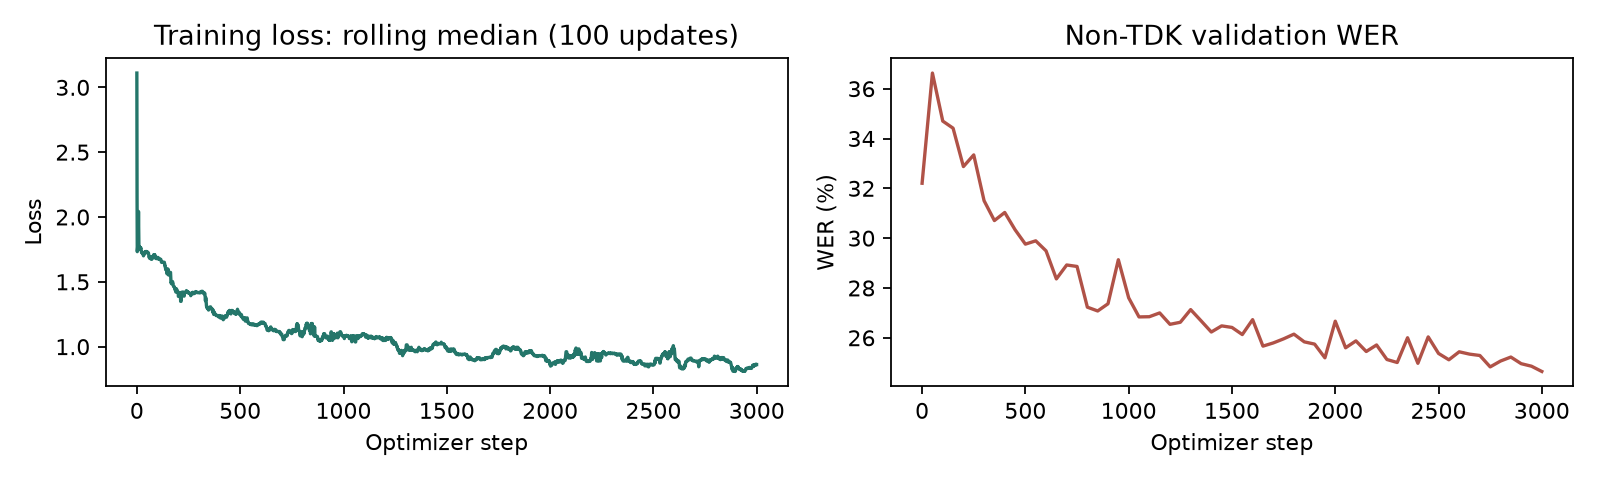

In [7]:
from pathlib import Path
import json
from IPython.display import Image, display
r = Path.cwd()
if not (r/'asr-train').exists(): r = r.parent
print(json.loads((r/'asr-train/results/E3/training-result.json').read_text()))
display(Image(filename=str(r/'asr-train/results/E3/training-curves.png')))